## 📊 What can data tell us about penalties in Hong Kong football?

**Competition:** Premier League, FA Cup, League Cup, Senior Shield    
**Methods:** Exploratory data analysis, data visualisation, hypothesis testing (Fisher's exact test), Wilson score intervals for binomial rates  
**Author:** [Oscar Yu](https://www.linkedin.com/in/oscar-yu-cheuk-chun/)  


**92 penalties. 44 matches. 4 competitions. Every one coded by hand from match video.**

There is no public penalty data for Hong Kong football, so I built the dataset myself: I watched the video for every penalty awarded in the 2025–26 season and coded where the ball went, which way the goalkeeper moved, and what happened next.

Each kick was entered one row at a time through a purpose-built logging form [penalty-data-collection](https://penalty-data-collection.vercel.app/). The surrounding match data (fixtures, lineups, events and the penalty awards themselves, for all four competitions) is published separately as [hk-football-2025-26-data](https://github.com/Yu-Oscar/hk-football-2025-26-data), built from official HKFA Data. That repo is how I knew which penalties existed to go and find video for.

---


## Headlines

**A shootout is a different kick.** In open play, 45 of 49 penalties went in. In a shootout that fell to 27 of 43. Keepers did the damage: they saved almost seven times as often once the tie went to spots. That is what you would expect if a shootout is not five kicks from the allocated taker, but a longer list, under different pressure.

**Going high is not edge but a trade off.** High and low convert at the same rate. High kicks are saved less often and missed more often; the two risks cancel. Takers already lift the ball more in shootouts, so that habit cannot explain why shootouts are harder.

**Left-footed takers scored fewer.** 11 of 21 left-footed kicks went in, compared to 61 of 71 right-footed. It is not one player, and it is not because left-footers took more shootouts. They aimed at the same places as everyone else. This is something to monitor, not a basis for any conclusion yet; 21 kicks is still a small sample.

**Guessing the right way is not enough.** When the keeper went with the ball they still conceded about 60%. Diving the correct way is the start of a save, not the save itself.

**Almost nobody defends the middle.** Keepers stayed central on a handful of kicks all season. The 11 central shots against a diving keeper produced no saves. Standing still looks tempting on paper; this season does not have the kicks to call it a tactic.


## Setup

Imports, a shared plotly style so every chart looks the same, and the path to the CSV in `data/`.

In [28]:
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy.stats import fisher_exact
from statsmodels.stats.proportion import proportion_confint

pd.set_option("display.max_columns", None)
pio.renderers.default = "png"

# Muted palette, shared by every chart.
INK = "#22303c"
ACCENT = "#1b6ca8"
MUTED = "#9bb0bf"
GOOD = "#2e8b57"
BAD = "#c1553b"
OUTCOME_COLOR = {"GOAL": GOOD, "SAVED": ACCENT, "MISSED": BAD}

DATA_PATH = Path("data/hk-penalties-2025-26/hong-kong-penalties-2526.csv")

def as_pct(numerator, denominator):
    """Rate as a percentage, one decimal place. Works on Series or plain numbers."""
    rate = numerator / denominator * 100
    return rate.round(1) if hasattr(rate, "round") else round(rate, 1)


def kick_label(count):
    """Sample size in words rather than notation."""
    return f"{count} kick" if count == 1 else f"{count} kicks"


def outcome_summary(frame, group_cols):
    """Count + GOAL/SAVED/MISSED breakdown and rates for each group."""
    out = (
        frame.groupby(list(group_cols), dropna=False)
        .agg(
            n=("outcome", "size"),
            goals=("outcome", lambda s: (s == "GOAL").sum()),
            saved=("outcome", lambda s: (s == "SAVED").sum()),
            missed=("outcome", lambda s: (s == "MISSED").sum()),
        )
        .reset_index()
    )
    out["conversion_rate"] = as_pct(out["goals"], out["n"])
    out["save_rate"] = as_pct(out["saved"], out["n"])
    return out


def compare_rates(summary, label_col, made_col="goals", labels=None):
    """Fisher exact p for made-vs-not between two rows of a summary table."""
    left, right = (labels if labels is not None
                   else summary[label_col].tolist()[:2])
    rows = summary.set_index(label_col)
    table = [
        [rows.loc[left, made_col], rows.loc[left, "n"] - rows.loc[left, made_col]],
        [rows.loc[right, made_col], rows.loc[right, "n"] - rows.loc[right, made_col]],
    ]
    return fisher_exact(table, alternative="two-sided")[1]


def with_intervals(frame, made_col, n_col="n"):
    """Attach a rate and its 95% Wilson interval to every row."""
    out = frame.copy()
    out["rate"] = as_pct(out[made_col], out[n_col])
    out["ci_low"] = 0.0
    out["ci_high"] = 0.0
    ok = out[n_col] > 0
    if ok.any():
        los, his = proportion_confint(
            out.loc[ok, made_col], out.loc[ok, n_col],
            alpha=0.05, method="wilson",
        )
        out.loc[ok, "ci_low"] = (los * 100).round(1)
        out.loc[ok, "ci_high"] = (his * 100).round(1)
    return out


def style_figure(fig, title, height=380, xaxis_title=None, showlegend=True):
    """House style for the bar and dot charts."""
    fig.update_traces(hoverinfo="skip", hovertemplate=None)
    fig.update_layout(
        title=dict(text=title, font=dict(size=17, color=INK), x=0.02, y=0.95),
        plot_bgcolor="white",
        paper_bgcolor="white",
        font=dict(family="Arial", size=12, color=INK),
        width=900,
        height=height,
        margin=dict(l=30, r=30, t=70, b=45),
        showlegend=showlegend,
        legend=dict(orientation="h", traceorder="normal",
                    yanchor="bottom", y=1.0, xanchor="right", x=1),
        hovermode=False,
    )
    fig.update_xaxes(title=xaxis_title, showgrid=True, gridcolor="#eef2f5",
                     zeroline=False, linecolor=MUTED)
    fig.update_yaxes(showgrid=False, zeroline=False, linecolor="white")
    return fig


def outcome_composition_figure(summary, label_col, title, height=340):
    """100% stacked GOAL/SAVED/MISSED bars, one row per group."""
    fig = go.Figure()
    for outcome, count_col in [("GOAL", "goals"), ("SAVED", "saved"), ("MISSED", "missed")]:
        share = as_pct(summary[count_col], summary["n"])
        fig.add_bar(
            y=summary[label_col], x=share, orientation="h", name=outcome,
            marker=dict(color=OUTCOME_COLOR[outcome], line=dict(color="white", width=2)),
            text=[f"{s:.1f}%" if s >= 7 else "" for s in share],
            textposition="inside",
            insidetextfont=dict(color="white", size=11, family="Arial Black"),
        )
    style_figure(fig, title, height=height, xaxis_title="Share of the group's kicks (%)")
    fig.update_layout(barmode="stack", bargap=0.4)
    fig.update_xaxes(range=[0, 100])
    return fig


def interval_figure(table, label_col, made_col, title, xaxis_title,
                    height=330, reference=None, reference_label=None,
                    marker_scale=1.4):
    """Rate per group with its 95% Wilson interval; marker size tracks sample size.

    Lower `marker_scale` when the groups run to dozens of kicks, or the markers
    grow wide enough to hide the intervals they sit on.
    """
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=table["rate"], y=table[label_col],
        error_x=dict(
            type="data", symmetric=False,
            array=table["ci_high"] - table["rate"],
            arrayminus=table["rate"] - table["ci_low"],
            color=MUTED, thickness=2, width=6,
        ),
        mode="markers+text",
        marker=dict(size=table["n"] * marker_scale + 9, color=ACCENT, opacity=0.85,
                    line=dict(color="white", width=1.5)),
        text=table["n"].map(lambda v: "  " + kick_label(v)),
        textposition="middle right", textfont=dict(size=11, color=INK),
        showlegend=False,
    ))
    if reference is not None:
        fig.add_vline(x=reference, line=dict(color=BAD, width=1.5, dash="dash"),
                      annotation_text=reference_label,
                      annotation_position="top left",
                      annotation_font=dict(color=BAD, size=11))
    style_figure(fig, title, height=height, xaxis_title=xaxis_title, showlegend=False)
    fig.update_xaxes(range=[0, 118])
    return fig



## The dataset

One row per penalty. Every field was read off the video by eye; there is no tracking data behind this.

| Column | Values | Meaning |
|---|---|---|
| `competition` | HKPL, FA Cup, Senior Shield, League Cup | Which competition |
| `match_date`, `match_id` | - | When and which match |
| `penalty_team`, `opponent_team` | - | Attacking side and defending side |
| `penalty_context` | IN_MATCH, SHOOTOUT | Kick during play, or in a shootout |
| `shootout_condition` | NORMAL, MUST_SCORE, CAN_WIN | Stakes of a shootout kick; empty for in-match kicks |
| `shooter`, `shooter_foot` | LEFT, RIGHT | Taker and the foot used |
| `goalkeeper` | - | Keeper facing the kick |
| `shot_horizontal` | LEFT, CENTRE, RIGHT | Which third of the goal the ball went towards |
| `shot_vertical` | HIGH, LOW | Above or below roughly the keeper's waist |
| `keeper_direction` | LEFT, CENTRE, RIGHT | Which way the keeper committed |
| `penalty_type` | NORMAL, HESITATION, PANENKA | Run-up style |
| `outcome` | GOAL, SAVED, MISSED | Result: a save and a miss are **not** the same event |
| `video_source` | URL | Match page the kick was coded from |

A conventions worth stating before any numbers appear:

- **`shot_horizontal` and `keeper_direction` use the same frame of reference**, so they can be compared directly to tell whether the keeper went the right way. Section 4 is built entirely on that comparison.

In [29]:
df = pd.read_csv(DATA_PATH)
df["match_date"] = pd.to_datetime(df["match_date"], format="%d %b %Y")

print(f"{len(df)} penalties  |  {df['match_id'].nunique()} matches  |  "
      f"{df['competition'].nunique()} competitions")
print(f"{df['shooter'].nunique()} shooters  |  {df['goalkeeper'].nunique()} goalkeepers")
print(f"Season window: {df['match_date'].min():%d %b %Y} to {df['match_date'].max():%d %b %Y}")


92 penalties  |  44 matches  |  4 competitions
56 shooters  |  19 goalkeepers
Season window: 30 Aug 2025 to 30 May 2026


## The questions

1. **How often do penalties actually go in?** The season baseline
2. **Does placement matter?** Where takers aim, and what actually converts
3. **Are shootouts different from in-match penalties**, and does pressure inside a shootout change anything?
4. **Does it matter whether the keeper guesses right?** Including whether a correct dive costs the taker accuracy, and how far the sample is from judging keepers who stay central
5. **Does the taker's foot matter?**
6. **What this dataset genuinely cannot answer**, and why that is worth saying out loud


---

# 1. The baseline: how often does a penalty go in?

Everything later in the notebook is a deviation from this one number, so it comes first.

Conversion rate:  78.3%   (72/92)
Keeper save rate: 15.2%   (14/92)
Off target:       6.5%   (6/92)


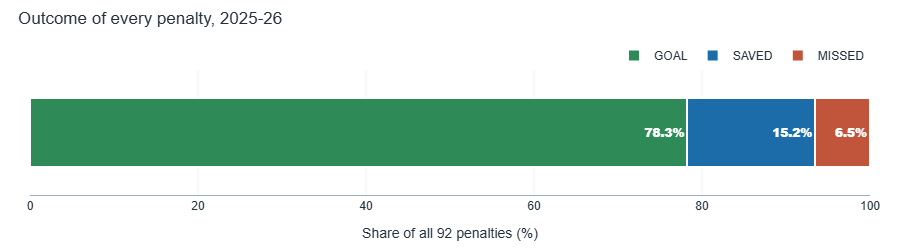

In [30]:
total = len(df)
goals = int((df["outcome"] == "GOAL").sum())
saved = int((df["outcome"] == "SAVED").sum())
missed = int((df["outcome"] == "MISSED").sum())

print(f"Conversion rate:  {as_pct(goals, total)}%   ({goals}/{total})")
print(f"Keeper save rate: {as_pct(saved, total)}%   ({saved}/{total})")
print(f"Off target:       {as_pct(missed, total)}%   ({missed}/{total})")

fig = go.Figure()
for label, count in [("GOAL", goals), ("SAVED", saved), ("MISSED", missed)]:
    pct = count / total * 100
    fig.add_bar(
        y=["season"], x=[pct], orientation="h", name=label,
        marker=dict(color=OUTCOME_COLOR[label], line=dict(color="white", width=2)),
        text=[f"{pct:.1f}%"], textposition="inside",
        insidetextfont=dict(color="white", size=12, family="Arial Black"),
    )

style_figure(fig, "Outcome of every penalty, 2025-26", height=250,
             xaxis_title=f"Share of all {total} penalties (%)")
fig.update_layout(barmode="stack", bargap=0.45)
fig.update_xaxes(range=[0, 100])
fig.update_yaxes(visible=False)
fig.show()

### Where the 92 kicks came from

,competition,n,IN_MATCH,SHOOTOUT,goals,saved,missed,conversion_rate,save_rate
0,FA Cup,40,6,34,28,10,2,70.0,25.0
1,HKPL,33,33,0,31,2,0,93.9,6.1
2,Senior Shield,14,5,9,9,2,3,64.3,14.3
3,League Cup,5,5,0,4,0,1,80.0,0.0


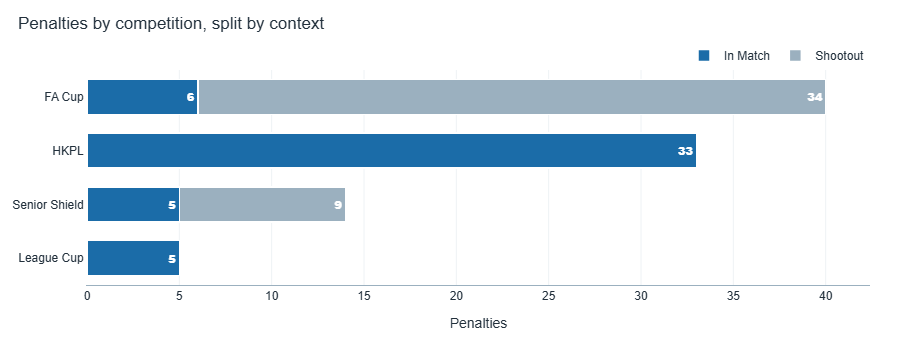

In [31]:
by_competition = (
    outcome_summary(df, ["competition"])
    .merge(
        df.pivot_table(
            index="competition", columns="penalty_context",
            values="penalty_id", aggfunc="count", fill_value=0,
        ).reset_index(),
        on="competition",
    )
    .sort_values("n")
    .reset_index(drop=True)
)

display(
    by_competition.sort_values("n", ascending=False)[[
        "competition", "n", "IN_MATCH", "SHOOTOUT",
        "goals", "saved", "missed", "conversion_rate", "save_rate",
    ]].reset_index(drop=True)
)

fig = go.Figure()
for context, color in [("IN_MATCH", ACCENT), ("SHOOTOUT", MUTED)]:
    fig.add_bar(
        y=by_competition["competition"], x=by_competition[context],
        orientation="h", name=context.replace("_", " ").title(),
        marker=dict(color=color, line=dict(color="white", width=1.5)),
        text=by_competition[context].map(lambda v: str(v) if v else ""),
        textposition="inside",
        insidetextfont=dict(color="white", size=11, family="Arial Black"),
    )

style_figure(fig, "Penalties by competition, split by context", height=340,
             xaxis_title="Penalties")
fig.update_layout(barmode="stack", bargap=0.35)
fig.update_xaxes(range=[0, by_competition["n"].max() * 1.06])
fig.show()

---

# 2. Placement: does it matter where you put it?

The scheme splits the goal into **three horizontal thirds** (`LEFT`, `CENTRE`, `RIGHT`) and **two heights** (`HIGH`, `LOW`), six target zones in all.

Two views of the same six zones, plotted onto the goal. First: **where the kicks went**, with bubble size and colour both showing the number of penalties aimed at that zone.

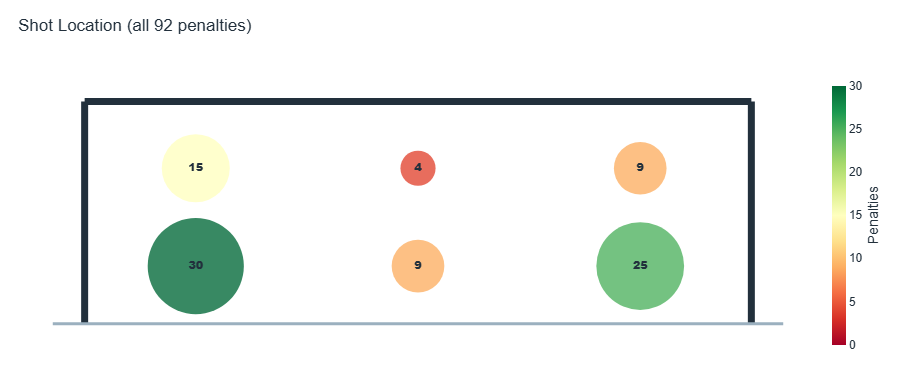

In [32]:
# Real goal dimensions (metres), so the frame is drawn to scale.
GOAL_W, GOAL_H = 7.32, 2.44
ZONE_X = {"LEFT": GOAL_W / 6, "CENTRE": GOAL_W / 2, "RIGHT": 5 * GOAL_W / 6}
ZONE_Y = {"HIGH": GOAL_H * 0.70, "LOW": GOAL_H * 0.26}

placement = outcome_summary(df, ["shot_horizontal", "shot_vertical"])
placement["x"] = placement["shot_horizontal"].map(ZONE_X)
placement["y"] = placement["shot_vertical"].map(ZONE_Y)
placement["share_of_kicks"] = as_pct(placement["n"], len(df))
placement["zone"] = placement["shot_vertical"] + " " + placement["shot_horizontal"]

BUBBLE_MAX = 68  # same size scale in both views, so they stay comparable
BUBBLE_SCALE = "RdYlGn"  # one colour scale for every goal-mouth bubble chart
RATE_RANGE = (40, 100)  # fixed span for conversion rate, so the views compare
def goal_frame():
    """Two posts, a crossbar and the goal line; no net, no grass."""
    post = dict(color=INK, width=7)
    return [
        dict(type="line", x0=0, y0=0, x1=0, y1=GOAL_H, line=post),
        dict(type="line", x0=GOAL_W, y0=0, x1=GOAL_W, y1=GOAL_H, line=post),
        dict(type="line", x0=0, y0=GOAL_H, x1=GOAL_W, y1=GOAL_H, line=post),
        dict(type="line", x0=-0.35, y0=0, x1=GOAL_W + 0.35, y1=0,
             line=dict(color=MUTED, width=3)),
    ]


def style_goal_figure(fig, title, colorbar_title):
    """Bubbles over a bare goal frame, locked to a true aspect ratio."""
    fig.update_traces(
        marker=dict(opacity=0.78, line=dict(width=0)),
        textfont=dict(size=11, color=INK, family="Arial Black"),
        hoverinfo="skip",
        hovertemplate=None,
    )
    fig.update_layout(
        title=dict(text=title, font=dict(size=17, color=INK), x=0.02, y=0.95),
        shapes=goal_frame(),
        plot_bgcolor="white",
        paper_bgcolor="white",
        font=dict(family="Arial", size=12, color=INK),
        width=900,
        height=390,
        margin=dict(l=30, r=10, t=60, b=20),
        hovermode=False,
        coloraxis_colorbar=dict(
            title=dict(text=colorbar_title, side="right"),
            thickness=14, len=0.9, y=0.5,
        ),
    )
    fig.update_xaxes(visible=False, range=[-0.6, GOAL_W + 0.6])
    fig.update_yaxes(visible=False, range=[-0.5, GOAL_H + 0.45],
                     scaleanchor="x", scaleratio=1)
    return fig


fig = px.scatter(
    placement, x="x", y="y",
    size="n", size_max=BUBBLE_MAX,
    color="n", color_continuous_scale=BUBBLE_SCALE,
    range_color=(0, placement["n"].max()),
    text="n",
)
style_goal_figure(fig, "Shot Location (all 92 penalties)", "Penalties")
fig.show()

**Takers crowd the bottom corners.** 55 of 92 kicks (59.8%) went low and to a side, and only 4 were aimed high through the middle. `LOW` accounts for 64 kicks (69.6%) against 28 high, and the central third is the least used of the three (13 kicks, 14.1%).

**Now the same zones coloured by how often they scored.** Bubble size still encodes volume, so a bright green bubble that is small cannot be read as a recommendation.

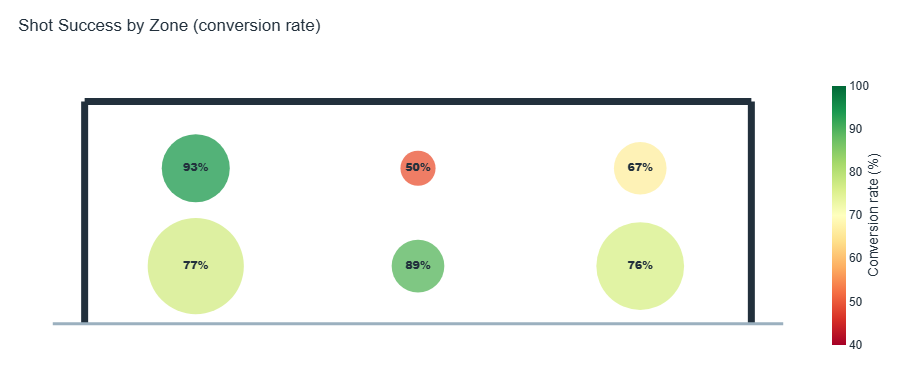

In [33]:
fig = px.scatter(
    placement, x="x", y="y",
    size="n", size_max=BUBBLE_MAX,
    color="conversion_rate", color_continuous_scale=BUBBLE_SCALE, range_color=RATE_RANGE,
    text=placement["conversion_rate"].map(lambda v: f"{v:.0f}%"),
)
style_goal_figure(fig, "Shot Success by Zone (conversion rate)", "Conversion rate (%)")
fig.show()

### What the two views show together

**The best-converting zone is not the busiest one.** `LEFT` + `HIGH` returned the highest conversion in the set off 15 kicks, and not one of those was saved. Meanwhile the most popular target, `LEFT` + `LOW`, converted at a clearly lower rate off double the volume.

**Down the middle is where it splits.** `CENTRE` + `LOW` did well, but `CENTRE` + `HIGH` is the worst zone on the board, however it is only 4 kicks. That is a coin flip's worth of evidence, not a finding.

**But collapse the zones and the height effect vanishes.** `HIGH` converts 78.6% across 28 kicks, `LOW` converts 78.1% across 64, the same number. What changes is *how* the kick fails: keepers saved 17.2% of low kicks but only 10.7% of high ones, while takers put 10.7% of high kicks off target against 4.7% of low ones. **Going high trades save risk for miss risk, and the two cancel out.** That trade-off is the real story of this section, and it is invisible in the zone grid.

By side, `LEFT` was both the most used (45 kicks) and the best converting (82.2%), ahead of `RIGHT` (73.5% across 34 kicks), but an 8.7-point gap on samples this size is suggestive at best.

The honest summary: **the six-zone grid mostly reflects small-sample noise; the two claims that survive aggregation are the low-corner concentration and the save/miss trade-off between high and low.**

The full breakdown, including how each zone did:

In [34]:
zone_table = (
    placement.sort_values("n", ascending=False)
    [[
        "shot_horizontal", "shot_vertical", "n", "share_of_kicks",
        "goals", "saved", "missed", "conversion_rate", "save_rate",
    ]]
    .reset_index(drop=True)
)
display(zone_table)

# Side and height on their own, where the denominators are large enough to trust.
print("By side:")
display(outcome_summary(df, ["shot_horizontal"]).sort_values("n", ascending=False))
print("By height:")
display(outcome_summary(df, ["shot_vertical"]).sort_values("n", ascending=False))

,shot_horizontal,shot_vertical,n,share_of_kicks,goals,saved,missed,conversion_rate,save_rate
0,LEFT,LOW,30,32.6,23,6,1,76.7,20.0
1,RIGHT,LOW,25,27.2,19,4,2,76.0,16.0
2,LEFT,HIGH,15,16.3,14,0,1,93.3,0.0
3,CENTRE,LOW,9,9.8,8,1,0,88.9,11.1
4,RIGHT,HIGH,9,9.8,6,2,1,66.7,22.2
5,CENTRE,HIGH,4,4.3,2,1,1,50.0,25.0


By side:


,shot_horizontal,n,goals,saved,missed,conversion_rate,save_rate
1,LEFT,45,37,6,2,82.2,13.3
2,RIGHT,34,25,6,3,73.5,17.6
0,CENTRE,13,10,2,1,76.9,15.4


By height:


,shot_vertical,n,goals,saved,missed,conversion_rate,save_rate
1,LOW,64,50,11,3,78.1,17.2
0,HIGH,28,22,3,3,78.6,10.7


---

# 3. In-match kicks vs shootouts

This is the one split in the dataset where the two groups are close to even in size (49 in-match, 43 shootout), so it is also the one comparison with enough weight behind it to test properly.

,penalty_context,n,goals,saved,missed,conversion_rate,save_rate
0,IN_MATCH,49,45,2,2,91.8,4.1
1,SHOOTOUT,43,27,12,4,62.8,27.9


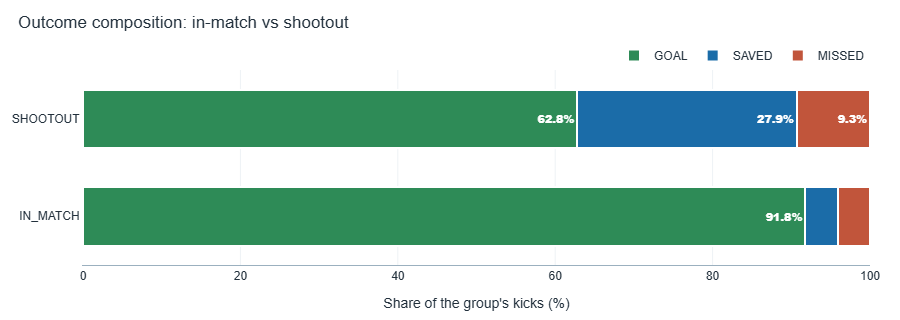

Conversion 91.8% vs 62.8%  ->  Fisher exact p = 0.0009
Save rate  4.1% vs 27.9%  ->  Fisher exact p = 0.0025


In [35]:
by_context = outcome_summary(df, ["penalty_context"])
display(by_context)

fig = outcome_composition_figure(
    by_context, "penalty_context",
    "Outcome composition: in-match vs shootout", height=320,
)
fig.show()

# Is the gap bigger than chance? Fisher exact on goal-vs-not, then save-vs-not.
p_goal = compare_rates(by_context, "penalty_context", "goals",
                       labels=["IN_MATCH", "SHOOTOUT"])
p_save = compare_rates(by_context, "penalty_context", "saved",
                       labels=["IN_MATCH", "SHOOTOUT"])
rates = by_context.set_index("penalty_context")
print(f"Conversion {rates.loc['IN_MATCH', 'conversion_rate']}% vs "
      f"{rates.loc['SHOOTOUT', 'conversion_rate']}%  ->  Fisher exact p = {p_goal:.4f}")
print(f"Save rate  {rates.loc['IN_MATCH', 'save_rate']}% vs "
      f"{rates.loc['SHOOTOUT', 'save_rate']}%  ->  Fisher exact p = {p_save:.4f}")

### The single biggest effect in the dataset

**In-match penalties converted 91.8% (45/49). Shootout kicks converted 62.8% (27/43).** A 29-point gap, and a Fisher exact test puts it at **p ≈ 0.0009** so this is not sampling noise.

The gap is almost entirely created by keepers. Keepers saved 4.1% of in-match kicks and 27.9% of shootout kicks (p ≈ 0.003), close to a sevenfold increase. Off-target misses also rose, from 4.1% to 9.3%, but from such small counts (2 and 4 kicks) that the change means little on its own.

So why? Two candidate explanations the data can actually speak to:

In [36]:
# Do takers aim differently when it is a shootout?
height_mix = pd.crosstab(df["penalty_context"], df["shot_vertical"])
height_share = as_pct(height_mix, height_mix.sum(axis=1).values.reshape(-1, 1))
print("Height mix by context (% of the group's kicks):")
display(height_share)

p_height = fisher_exact([
    [height_mix.loc["IN_MATCH", "HIGH"], height_mix.loc["IN_MATCH", "LOW"]],
    [height_mix.loc["SHOOTOUT", "HIGH"], height_mix.loc["SHOOTOUT", "LOW"]],
], alternative="two-sided")[1]
print(f"HIGH share {height_share.loc['IN_MATCH', 'HIGH']}% vs "
      f"{height_share.loc['SHOOTOUT', 'HIGH']}%  ->  Fisher exact p = {p_height:.4f}")

# And do keepers behave differently?
df["keeper_commit"] = df["keeper_direction"].map(
    {"LEFT": "SIDE", "RIGHT": "SIDE", "CENTRE": "CENTRE"}
)
keeper_commit_ct = pd.crosstab(df["penalty_context"], df["keeper_commit"])
print("\nKeeper commitment by context:")
display(keeper_commit_ct)

# Show p-value for difference in keeper commitment (CENTRE vs SIDE) by context
p_commit = fisher_exact([
    [keeper_commit_ct.loc["IN_MATCH", "CENTRE"], keeper_commit_ct.loc["IN_MATCH", "SIDE"]],
    [keeper_commit_ct.loc["SHOOTOUT", "CENTRE"], keeper_commit_ct.loc["SHOOTOUT", "SIDE"]],
], alternative="two-sided")[1]
print(f"Commit SIDE {keeper_commit_ct.loc['IN_MATCH', 'SIDE']} of 49 (in-match) vs "
      f"{keeper_commit_ct.loc['SHOOTOUT', 'SIDE']} of 43 (shootout)  ->  Fisher exact p = {p_commit:.4f}")


Height mix by context (% of the group's kicks):


shot_vertical,HIGH,LOW
penalty_context,,
IN_MATCH,20.4,79.6
SHOOTOUT,41.9,58.1


HIGH share 20.4% vs 41.9%  ->  Fisher exact p = 0.0402

Keeper commitment by context:


keeper_commit,CENTRE,SIDE
penalty_context,,
IN_MATCH,2,47
SHOOTOUT,3,40


Commit SIDE 47 of 49 (in-match) vs 40 of 43 (shootout)  ->  Fisher exact p = 0.6617


**Takers do aim differently.** 41.9% of shootout kicks went high, against 20.4% of in-match kicks (p ≈ 0.04); under shootout pressure, takers lift the ball more often. But recall from section 2 that height barely moves conversion, so **this cannot explain the 29-point gap.**

**Keepers do not behave differently.** They committed to a side on 47 of 49 in-match kicks and 40 of 43 shootout kicks, essentially identical. Whatever changes in a shootout, it is not the keeper's basic choice to dive.

Which leaves the interesting conclusion: **the gap is not explained by anything else this dataset measures.** No difference in keeper strategy, and a placement shift cannot explain. What is left is the part the coding cannot see: kick quality under pressure, keeper readiness, and who is taking the fifth kick rather than the first.

### Does the stake of the individual shootout kick matter?

Each shootout kick is coded with what was riding on it:

- `NORMAL`: an ordinary kick in the sequence
- `MUST_SCORE`: a miss loses the shootout
- `CAN_WIN`: a goal wins it

This is the most tempting split in the dataset and the weakest. Below, each condition's conversion rate is drawn **with a 95% Wilson confidence interval**, which is the honest way to show a rate built on three or four kicks.

,shootout_condition,n,goals,saved,missed,conversion_rate,save_rate
0,CAN_WIN,3,2,1,0,66.7,33.3
1,MUST_SCORE,4,2,1,1,50.0,25.0
2,NORMAL,36,23,10,3,63.9,27.8


,pressure,n,goals,saved,missed,conversion_rate,save_rate
0,NORMAL,36,23,10,3,63.9,27.8
1,PRESSURE,7,4,2,1,57.1,28.6


,group,goals,n,rate,ci_low,ci_high
0,CAN_WIN,2,3,66.7,20.8,93.9
1,MUST_SCORE,2,4,50.0,15.0,85.0
2,PRESSURE (pooled),4,7,57.1,25.0,84.2
3,NORMAL,23,36,63.9,47.6,77.5


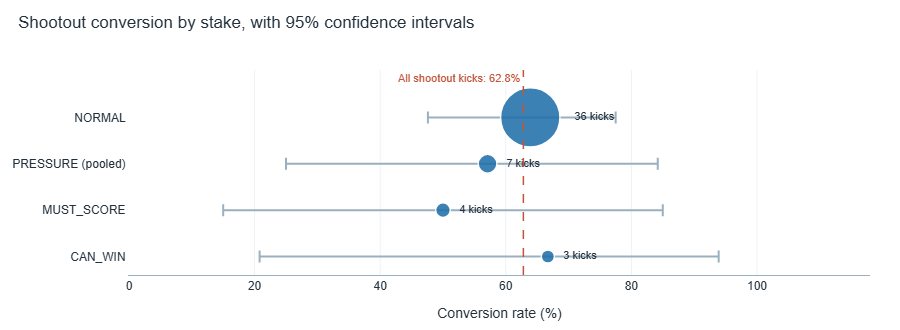

NORMAL vs pooled PRESSURE  ->  Fisher exact p = 1.0000


In [37]:
shootout_kicks = df[df["penalty_context"] == "SHOOTOUT"].copy()
by_condition = outcome_summary(shootout_kicks, ["shootout_condition"])

# MUST_SCORE and CAN_WIN are a handful of kicks each, so also pool them.
shootout_kicks["pressure"] = shootout_kicks["shootout_condition"].where(
    shootout_kicks["shootout_condition"] == "NORMAL", "PRESSURE"
)
by_pressure = outcome_summary(shootout_kicks, ["pressure"])

display(by_condition)
display(by_pressure)

stakes = pd.concat([
    by_condition.rename(columns={"shootout_condition": "group"})[["group", "goals", "n"]],
    by_pressure.loc[by_pressure["pressure"] == "PRESSURE"]
    .rename(columns={"pressure": "group"})
    .assign(group="PRESSURE (pooled)")[["group", "goals", "n"]],
])
stakes = with_intervals(stakes, "goals").sort_values("n").reset_index(drop=True)
display(stakes)

shootout_rate = as_pct((shootout_kicks["outcome"] == "GOAL").sum(), len(shootout_kicks))
fig = interval_figure(
    stakes, "group", "goals",
    "Shootout conversion by stake, with 95% confidence intervals",
    "Conversion rate (%)",
    reference=shootout_rate,
    reference_label=f"All shootout kicks: {shootout_rate}%",
)
fig.show()

p_pressure = compare_rates(by_pressure, "pressure", "goals",
                           labels=["NORMAL", "PRESSURE"])
print(f"NORMAL vs pooled PRESSURE  ->  Fisher exact p = {p_pressure:.4f}")

### Nothing here, and the intervals show why

`MUST_SCORE` came out at 50% and `CAN_WIN` at 66.7%, which invites a story about nerve, until you notice those are **2 of 4** and **2 of 3** kicks. Their confidence intervals span roughly 15–85% and 21–94%: wide enough to contain almost any claim you might want to make.

Pooling both into a single `PRESSURE` group gives 4 of 7 (57.1%) against `NORMAL` at 23 of 36 (63.9%). A Fisher exact test on that comparison returns **p = 1.0** so literally no evidence of a difference.

**The honest reading: with 7 high-stakes kicks in the whole season, this question is unanswerable from one season of Hong Kong football.** The `shootout_condition` field is worth keeping, over longer periold it would have enough kicks to say something but here it does not mean much.

What section 3 does establish is the thing that matters: **the shootout effect itself is large and statistically solid, and it works through keeper saves.**

---

# 4. The keeper: does diving the right way cost the taker accuracy, and can 5 kicks justify staying central?

Because `keeper_direction` and `shot_horizontal` were coded in the same frame of reference, they can be compared kick by kick. That turns a subjective question (did the keeper read it?) into a column.

A keeper **matched** the kick when they committed to the same third the ball was heading for. It happened on 48 of 92 kicks (52.2%), which is roughly what you would expect from a three-way guess weighted towards the sides.

Getting the direction right obviously helps a keeper make saves, and the first chart below confirms that in the strongest terms the dataset offers. The two questions this section actually tries to answer are the ones behind it:

1. **Does a keeper who goes the right way makes the taker miss more?** A save is the keeper's doing; a shot off target is the taker's error. If a correctly-read dive rushes takers into worse contact, it should show up as a higher off-target rate, not only as a higher save rate.
2. **Can this sample judge the "keepers should stand still" idea at all?** Keepers stayed central on 5 of 92 kicks. Rather than rank that against diving, the question here is whether 5 kicks could settle it or how many it would take.


,group,n,missed,rate,ci_low,ci_high
0,Went the right way,48,5,10.4,4.5,22.2
1,Went the wrong way,44,1,2.3,0.4,11.8


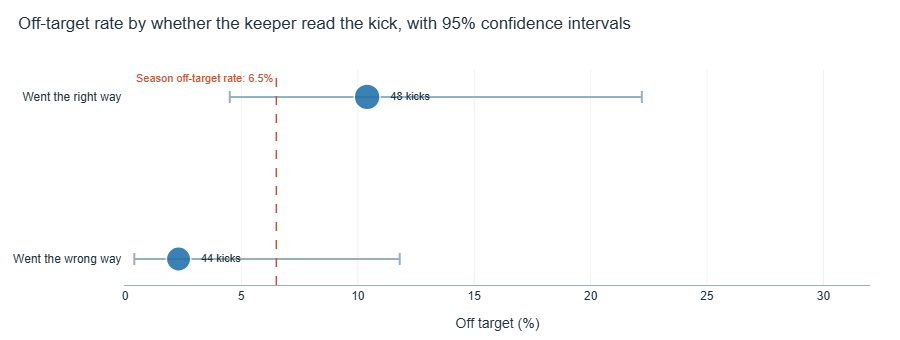

In [38]:
df["keeper_matched"] = df["keeper_direction"] == df["shot_horizontal"]
df["guess"] = df["keeper_matched"].map({True: "Went the right way",
                                        False: "Went the wrong way"})
by_guess = outcome_summary(df, ["guess"])

accuracy = with_intervals(
    by_guess.rename(columns={"guess": "group"})[["group", "n", "missed"]], "missed"
)
display(accuracy)

season_miss = as_pct(int((df["outcome"] == "MISSED").sum()), len(df))
fig = interval_figure(
    accuracy.sort_values("rate"), "group", "missed",
    "Off-target rate by whether the keeper read the kick, with 95% confidence intervals",
    "Off target (%)", height=340,
    reference=season_miss,
    reference_label=f"Season off-target rate: {season_miss}%",
    marker_scale=0.35,
)
# Every value here sits under 25%, so the shared 0-118% span would flatten the
# intervals this chart exists to show.
fig.update_xaxes(range=[0, 32])
fig.show()

### The accuracy question comes back empty

**A correctly-read dive did not measurably make takers miss.** Kicks where the keeper matched went off target 10.4% of the time (5 of 48); kicks where the keeper went the wrong way went off target 2.3% of the time (1 of 44). That is the direction a "keeper presence rushes the taker" story would predict, and it does not survive a test: **Fisher exact p ≈ 0.21**. The intervals above tell the same story visually: 4.5–22.2% against 0.4–11.8%, overlapping across most of their range, with both bars straddling the season off-target rate.

The reason is the denominator rather than the effect. **The season produced only 6 off-target penalties in total**, so even a real accuracy effect of this size could not separate from noise here.

That leaves the second question. Keepers hardly ever stayed central, so the counts below are everything this season has to say about it:

In [39]:
print("Kicks aimed down the middle, by what the keeper did:")
centre_shots = df[df["shot_horizontal"] == "CENTRE"]
display(pd.crosstab(
    centre_shots["keeper_direction"].eq("CENTRE")
    .map({True: "Keeper stayed central", False: "Keeper dived to a side"}),
    centre_shots["outcome"],
))

# Staying central is a strategy question, so the useful output is not a ranking
# but how far this sample is from being able to answer it.
central = df[df["keeper_direction"] == "CENTRE"]
dived = df[df["keeper_direction"] != "CENTRE"]
central_saves = int((central["outcome"] == "SAVED").sum())
dived_saves = int((dived["outcome"] == "SAVED").sum())
lo, hi = proportion_confint(central_saves, len(central), alpha=0.05, method="wilson")
low, high = lo * 100, hi * 100

print(f"\nStayed central: {central_saves} saves from {kick_label(len(central))}"
      f" = {as_pct(central_saves, len(central))}%"
      f"  (95% CI {low:.1f}% to {high:.1f}%)")
print(f"Dived:          {dived_saves} saves from {kick_label(len(dived))}"
      f" = {as_pct(dived_saves, len(dived))}%")
dived_table = [dived_saves, len(dived) - dived_saves]
p_central = fisher_exact([
    [central_saves, len(central) - central_saves],
    dived_table,
], alternative="two-sided")[1]
print(f"Central vs dived  ->  Fisher exact p = {p_central:.4f}")

# If the observed central save rate held, how many such kicks would settle it?
observed = central_saves / len(central)
for size in range(len(central), 500):
    saves_at_size = round(observed * size)
    if fisher_exact([
        [saves_at_size, size - saves_at_size],
        dived_table,
    ], alternative="two-sided")[1] < 0.05:
        print(f"Holding that {as_pct(central_saves, len(central))}% rate, it would take "
              f"{kick_label(size)} of keepers standing still to clear p < 0.05.")
        break

Kicks aimed down the middle, by what the keeper did:


outcome,GOAL,MISSED,SAVED
keeper_direction,,,
Keeper dived to a side,10,1,0
Keeper stayed central,0,0,2



Stayed central: 2 saves from 5 kicks = 40.0%  (95% CI 11.8% to 76.9%)
Dived:          12 saves from 87 kicks = 13.8%
Central vs dived  ->  Fisher exact p = 0.1646
Holding that 40.0% rate, it would take 9 kicks of keepers standing still to clear p < 0.05.


### The one strategy nobody tried, and how far the sample is from judging it

The same comparison exposes a gap in keeper behaviour. **Keepers stayed central on only 5 of 92 kicks (5.4%)**, and on 2 of those 5 the shot came straight down the middle, and both were saved.

Meanwhile, of the 13 kicks aimed down the middle, keepers had already dived to a side on 11 of them. Those 11 kicks produced **10 goals, 1 off-target, and no saves.**

**On its face, standing still looks excellent: 2 saves from 5 kicks is a 40% save rate against 13.8% for every dive in the season.** That is the most tempting number in the notebook, but five kicks put the 95% interval at **11.8% to 76.9%**, which contains the diving rate comfortably, and the comparison returns **Fisher exact p ≈ 0.16**. A single different outcome can move the rate significantly.

**The sample-size answer is more useful than the rate, and it is unusually close.** Holding that same 40% rate, it would take **9 kicks** of keepers standing still to clear p < 0.05, only 4 more than this season supplied. So it needs roughly one more season of the same behaviour, or one competition where keepers try it slightly more often. Worth stating plainly all the same: **holding the rate constant while adding kicks is an assumption, not a prediction.** Nine central kicks could just as easily land on 2 saves and settle nothing.

Two further reasons not to read this as advice. Standing still against a well-struck corner is exactly where diving pays, so a keeper who stayed central on *every* kick would not keep a 40% rate. And keepers who stand still may be choosing to do so against takers they have already read, which the dataset cannot separate.

What the data does support is narrower and still interesting: **the central third of the goal was effectively undefended this season**, because keepers had almost always vacated it before the ball was struck. That is a description of what happened, and it needs no test.

---

# 5. Does the taker's foot matter?


,shooter_foot,n,goals,saved,missed,conversion_rate,save_rate
0,LEFT,21,11,7,3,52.4,33.3
1,RIGHT,71,61,7,3,85.9,9.9


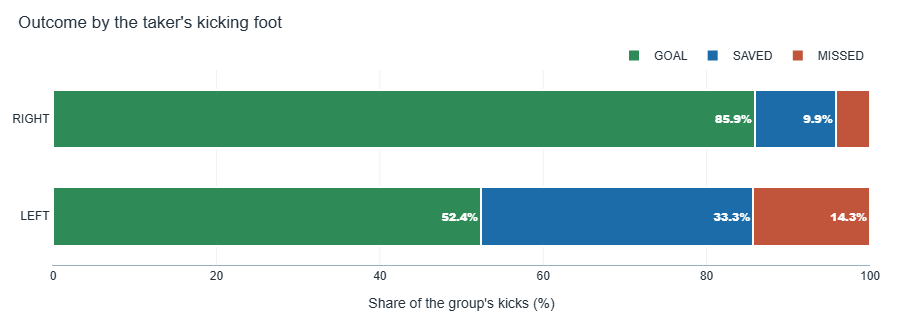

Conversion left 52.4% vs right 85.9%  ->  Fisher exact p = 0.0023
Save rate  left 33.3% vs right 9.9%  ->  Fisher exact p = 0.0149


In [40]:
by_foot = outcome_summary(df, ["shooter_foot"])
display(by_foot)

fig = outcome_composition_figure(
    by_foot, "shooter_foot",
    "Outcome by the taker's kicking foot", height=320,
)
fig.show()

p_goal = compare_rates(by_foot, "shooter_foot", "goals", labels=["LEFT", "RIGHT"])
p_save = compare_rates(by_foot, "shooter_foot", "saved", labels=["LEFT", "RIGHT"])
rates = by_foot.set_index("shooter_foot")
print(f"Conversion left {rates.loc['LEFT', 'conversion_rate']}% vs "
      f"right {rates.loc['RIGHT', 'conversion_rate']}%  ->  Fisher exact p = {p_goal:.4f}")
print(f"Save rate  left {rates.loc['LEFT', 'save_rate']}% vs "
      f"right {rates.loc['RIGHT', 'save_rate']}%  ->  Fisher exact p = {p_save:.4f}")

**Left-footed takers converted 52.4% (11 of 21). Right-footed takers converted 85.9% (61 of 71).** A 33-point gap at **p ≈ 0.002**, and it shows up in both failure modes: left-footers were saved three times as often (33.3% vs 9.9%) and missed the target more often too (14.3% vs 4.2%).

A 21-kick group producing a headline gap is exactly where small-sample analysis goes wrong, so here are the three ways it could be an artefact, and what the data says to each.

Left-foot kicks: 21 taken by 18 different players (most by any one player: 3)


penalty_context,IN_MATCH,SHOOTOUT
shooter_foot,,
LEFT,9,12
RIGHT,40,31


Foot vs context association  ->  Fisher exact p = 0.3249


,group,n,goals,rate,ci_low,ci_high
0,"Left foot, in-match",9,6,66.7,35.4,87.9
1,"Right foot, in-match",40,39,97.5,87.1,99.6
2,"Left foot, shootout",12,5,41.7,19.3,68.0
3,"Right foot, shootout",31,22,71.0,53.4,83.9


IN_MATCH: left vs right  ->  Fisher exact p = 0.0165
SHOOTOUT: left vs right  ->  Fisher exact p = 0.0920


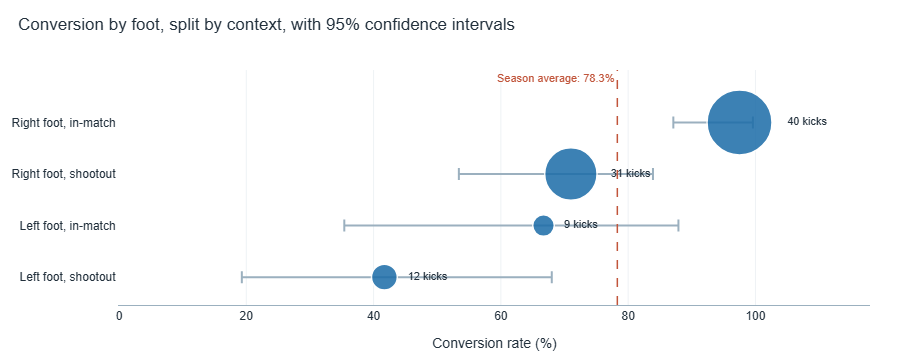

In [41]:
# 1. Is it one bad left-footed taker dragging the group down?
left_foot = df[df["shooter_foot"] == "LEFT"]
print(f"Left-foot kicks: {len(left_foot)} taken by "
      f"{left_foot['shooter'].nunique()} different players "
      f"(most by any one player: {left_foot['shooter'].value_counts().max()})")

# 2. Are left-footers over-represented in shootouts, where everyone converts less?
foot_context = pd.crosstab(df["shooter_foot"], df["penalty_context"])
display(foot_context)
p_mix = fisher_exact(foot_context.values, alternative="two-sided")[1]
print(f"Foot vs context association  ->  Fisher exact p = {p_mix:.4f}")

# 3. Does the gap survive inside each context separately?
foot_by_context = outcome_summary(df, ["penalty_context", "shooter_foot"])
foot_by_context["group"] = (
    foot_by_context["shooter_foot"].str.capitalize() + " foot, "
    + foot_by_context["penalty_context"].str.replace("_", "-").str.lower()
)
foot_by_context = with_intervals(foot_by_context, "goals")
display(foot_by_context[["group", "n", "goals", "rate", "ci_low", "ci_high"]])

for context in ["IN_MATCH", "SHOOTOUT"]:
    subset = foot_by_context[foot_by_context["penalty_context"] == context]
    p = compare_rates(subset, "shooter_foot", "goals", labels=["LEFT", "RIGHT"])
    print(f"{context}: left vs right  ->  Fisher exact p = {p:.4f}")

fig = interval_figure(
    foot_by_context.sort_values("rate"), "group", "goals",
    "Conversion by foot, split by context, with 95% confidence intervals",
    "Conversion rate (%)", height=360,
    reference=as_pct(int((df["outcome"] == "GOAL").sum()), len(df)),
    reference_label="Season average: 78.3%",
)
fig.show()

### It survives the checks

**It is not one player.** The 21 left-footed kicks were taken by 18 different players, and no one took more than 3. This is a property of the group, not of one wayward individual.

**It is not a shootout artefact.** Left-footers were not meaningfully more likely to be taking shootout kicks (p ≈ 0.32), so the section 3 effect is not hiding inside this one.

**It holds inside each context.** In-match, left-footers converted 66.7% against 97.5% for right-footers (p ≈ 0.02). In shootouts, 41.7% against 71.0%, the same direction and a similar size, though at 12 kicks it only reaches p ≈ 0.09 on its own. The confidence intervals make the pattern plain: both left-foot groups sit below the season average, both right-foot groups above it.

**The limits.** 21 kicks is 21 kicks; the interval on that 52.4% still runs from roughly 32% to 72%. Second, and more interesting, this dataset cannot tell you *why*.

### Do the two feet aim at different places?

If left-footers convert less, the first thing to check is whether they are simply aiming somewhere worse. The same goal-mouth view as section 2, now split by kicking foot.

One change for a fair comparison: there are 71 right-footed kicks and only 21 left-footed ones, so **bubble size and colour show each zone's share of that foot's own kicks**, not the raw count. Both charts use an identical scale, so the two are directly comparable.

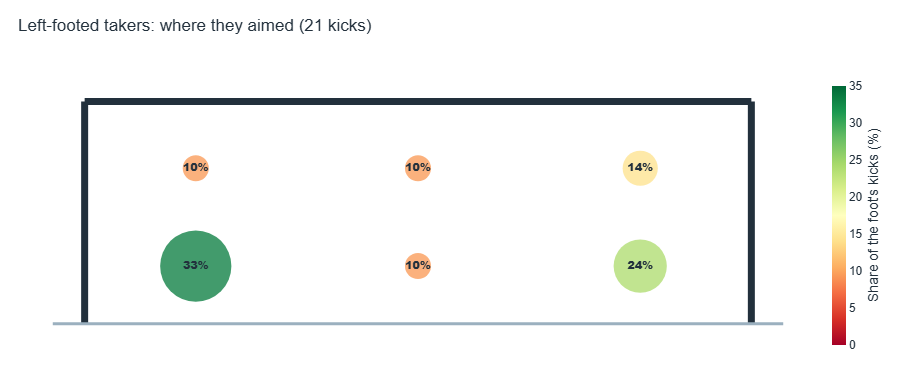

In [42]:
def foot_placement_figure(frame, title):
    """Goal-mouth view of one group's placement, scaled to its share of kicks."""
    zones = outcome_summary(frame, ["shot_horizontal", "shot_vertical"])
    zones["share"] = as_pct(zones["n"], len(frame))
    zones["zone"] = zones["shot_vertical"] + " " + zones["shot_horizontal"]
    zones["x"] = zones["shot_horizontal"].map(ZONE_X)
    zones["y"] = zones["shot_vertical"].map(ZONE_Y)

    fig = go.Figure(go.Scatter(
        x=zones["x"], y=zones["y"], mode="markers+text",
        # Linear diameter on a fixed scale, so both figures stay comparable.
        marker=dict(size=zones["share"] * 1.9 + 8,
                    color=zones["share"], coloraxis="coloraxis"),
        text=zones["share"].map(lambda v: f"{v:.0f}%"),
    ))
    fig.update_layout(coloraxis=dict(colorscale=BUBBLE_SCALE, cmin=0, cmax=35))
    style_goal_figure(fig, title, "Share of the foot's kicks (%)")
    return fig, zones


# One figure per cell: plotly's iframe renderer keys its output file on
# the cell number, so a second figure here would overwrite this one.
left_foot = df[df["shooter_foot"] == "LEFT"]
right_foot = df[df["shooter_foot"] == "RIGHT"]

fig, left_zones = foot_placement_figure(
    left_foot, f"Left-footed takers: where they aimed ({len(left_foot)} kicks)")
fig.show()

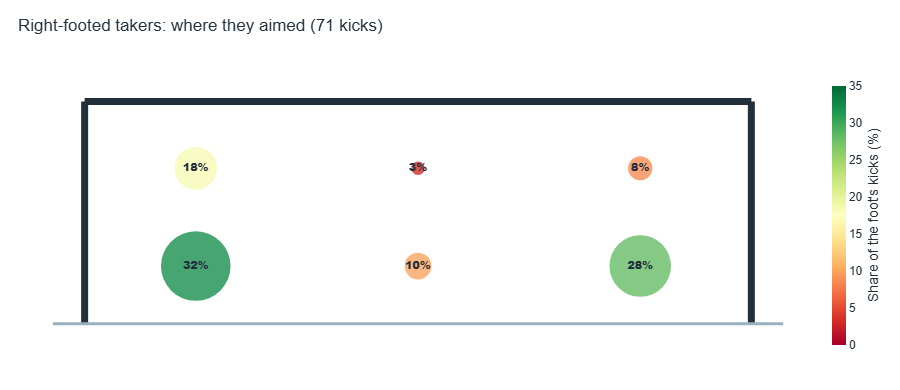

In [43]:
fig, right_zones = foot_placement_figure(
    right_foot, f"Right-footed takers: where they aimed ({len(right_foot)} kicks)")
fig.show()

In [44]:
# Marginals side by side, as shares of each foot's own kicks.
for column, label in [("shot_horizontal", "Side"), ("shot_vertical", "Height")]:
    counts = pd.crosstab(df["shooter_foot"], df[column])
    shares = as_pct(counts, counts.sum(axis=1).values.reshape(-1, 1))
    print(f"{label}: share of each foot's kicks (%):")
    display(shares)

# Is any of that difference real, or is it 21 kicks wobbling?
side_counts = pd.crosstab(df["shooter_foot"], df["shot_horizontal"])
height_counts = pd.crosstab(df["shooter_foot"], df["shot_vertical"])
p_side = fisher_exact([
    [side_counts.loc["LEFT", "LEFT"], side_counts.loc["LEFT", "RIGHT"]],
    [side_counts.loc["RIGHT", "LEFT"], side_counts.loc["RIGHT", "RIGHT"]],
], alternative="two-sided")[1]
p_centre = fisher_exact([
    [side_counts.loc["LEFT", "CENTRE"], side_counts.loc["LEFT", ["LEFT", "RIGHT"]].sum()],
    [side_counts.loc["RIGHT", "CENTRE"], side_counts.loc["RIGHT", ["LEFT", "RIGHT"]].sum()],
], alternative="two-sided")[1]
p_height = fisher_exact([
    [height_counts.loc["LEFT", "HIGH"], height_counts.loc["LEFT", "LOW"]],
    [height_counts.loc["RIGHT", "HIGH"], height_counts.loc["RIGHT", "LOW"]],
], alternative="two-sided")[1]
print(f"Left third vs right third, by foot  ->  Fisher exact p = {p_side:.4f}")
print(f"Centre vs the two sides, by foot    ->  Fisher exact p = {p_centre:.4f}")
print(f"High vs low, by foot                ->  Fisher exact p = {p_height:.4f}")

# Did keepers read one foot better than the other?
matched_counts = pd.crosstab(df["shooter_foot"], df["keeper_matched"])
p_matched = fisher_exact([
    [matched_counts.loc["LEFT", True], matched_counts.loc["LEFT", False]],
    [matched_counts.loc["RIGHT", True], matched_counts.loc["RIGHT", False]],
], alternative="two-sided")[1]
matched_share = as_pct(matched_counts[True], matched_counts.sum(axis=1))
print(f"\nKeeper went the right way on {matched_share['LEFT']}% of left-footed kicks "
      f"vs {matched_share['RIGHT']}% of right-footed  ->  Fisher exact p = {p_matched:.4f}")

Side: share of each foot's kicks (%):


shot_horizontal,CENTRE,LEFT,RIGHT
shooter_foot,,,
LEFT,19.0,42.9,38.1
RIGHT,12.7,50.7,36.6


Height: share of each foot's kicks (%):


shot_vertical,HIGH,LOW
shooter_foot,,
LEFT,33.3,66.7
RIGHT,29.6,70.4


Left third vs right third, by foot  ->  Fisher exact p = 0.7853
Centre vs the two sides, by foot    ->  Fisher exact p = 0.4841
High vs low, by foot                ->  Fisher exact p = 0.7901

Keeper went the right way on 66.7% of left-footed kicks vs 47.9% of right-footed  ->  Fisher exact p = 0.1449


### They aim at the same places, which makes the gap stranger

**The two maps are near copies of each other.** Both feet put roughly a third of their kicks into the low-left zone (33.3% left-footed, 32.4% right-footed), both favour the left third overall, both keep about 70% of kicks low, and both largely avoid the centre.

None of the small differences survive a test:

| Comparison | Left-footed | Right-footed | Fisher exact |
|---|---|---|---|
| Left third vs right third | 9 vs 8 | 36 vs 26 | p ≈ 0.79 |
| Centre vs the two sides | 4 vs 17 | 9 vs 62 | p ≈ 0.48 |
| High vs low | 7 vs 14 | 21 vs 50 | p ≈ 0.79 |

There is **no detectable difference in where the two feet aim**, and in particular no sign of the mirror-image pattern you might expect if takers were favouring their natural side.

**This makes the section 5 result harder to explain.** Left-footers were not picking worse targets; they chose the same zones as everyone else and simply came away with fewer goals. So the conversion gap has to live in execution or in how keepers respond, not in shot selection.


---

# 6. What this dataset cannot answer

### Individual players cannot be ranked

The busiest goalkeeper in the season faced 14 penalties. Six keepers faced 8 or more. That is enough to describe them, but not enough to separate them.

,goalkeeper,n,saves,goals_against,rate,ci_low,ci_high
0,CASSARO USART Ian,5,1,4,20.0,3.6,62.4
1,LI Hon Ho,8,0,8,0.0,0.0,32.4
2,PONG Cheuk Hei,8,2,6,25.0,7.1,59.1
3,YIP Ka Yu,9,2,6,22.2,6.3,54.7
4,TSE Ka Wing,10,4,5,40.0,16.8,68.7
5,LEUNG Hing Kit,11,0,9,0.0,0.0,25.9
6,DA SILVA ARGOLO Paulo Cesar,14,4,8,28.6,11.7,54.6


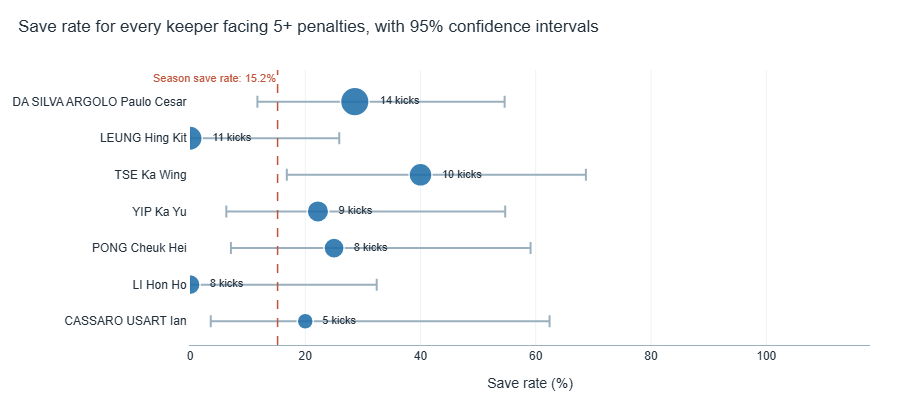

In [45]:
keepers = (
    df.groupby("goalkeeper")
    .agg(n=("outcome", "size"),
         saves=("outcome", lambda s: (s == "SAVED").sum()),
         goals_against=("outcome", lambda s: (s == "GOAL").sum()))
    .reset_index()
)
ranked_keepers = (
    with_intervals(keepers[keepers["n"] >= 5], "saves")
    .sort_values("n")
    .reset_index(drop=True)
)
display(ranked_keepers[["goalkeeper", "n", "saves", "goals_against",
                        "rate", "ci_low", "ci_high"]])

season_save_rate = as_pct(int((df["outcome"] == "SAVED").sum()), len(df))
fig = interval_figure(
    ranked_keepers, "goalkeeper", "saves",
    "Save rate for every keeper facing 5+ penalties, with 95% confidence intervals",
    "Save rate (%)", height=400,
    reference=season_save_rate,
    reference_label=f"Season save rate: {season_save_rate}%",
)
fig.show()

56 shooters took a penalty. 39 of them took exactly one.
Players with a perfect record: 7 (minimum 3 kicks)


,shooter,n,goals,rate,ci_low,ci_high
0,BATISTA RAMOS Kayron,3,2,66.7,20.8,93.9
1,CAMARGO Everton,3,3,100.0,43.9,100.0
2,FIGUEIREDO PEREIRA Stefan,3,3,100.0,43.9,100.0
3,SEVERO BURKATT Mikael,4,2,50.0,15.0,85.0
4,MARTINEZ ORTIZ Leandro,4,4,100.0,51.0,100.0
5,OKUBO Yu,4,4,100.0,51.0,100.0
6,PERAL DE LIMA Patrick,4,4,100.0,51.0,100.0
7,TORRES SARTORI Igor,4,4,100.0,51.0,100.0
8,SALUSTIANO DE JESUS SILVA Samuel,8,8,100.0,67.6,100.0


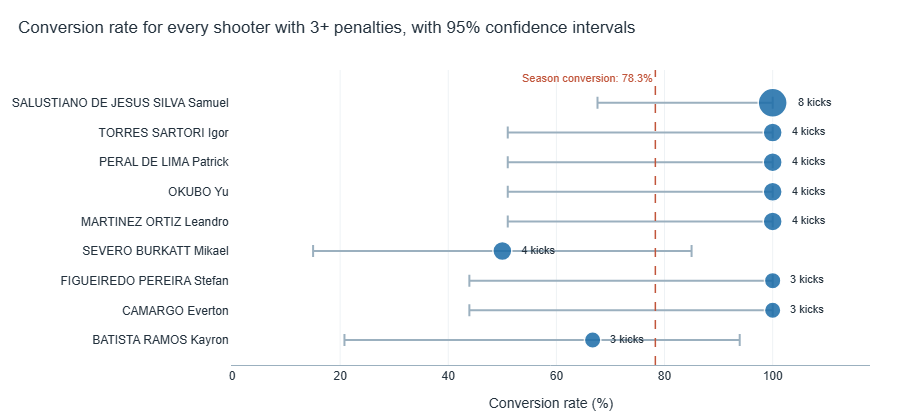

In [46]:
# The shooter board has the opposite problem: perfect records on tiny samples.
shooters = (
    df.groupby("shooter")
    .agg(n=("outcome", "size"),
         goals=("outcome", lambda s: (s == "GOAL").sum()))
    .reset_index()
)
ranked_shooters = (
    with_intervals(shooters[shooters["n"] >= 3], "goals")
    .sort_values(["n", "rate"])
    .reset_index(drop=True)
)
print(f"{len(shooters)} shooters took a penalty. "
      f"{(shooters['n'] == 1).sum()} of them took exactly one.")
print(f"Players with a perfect record: "
      f"{((shooters['goals'] == shooters['n']) & (shooters['n'] >= 3)).sum()} "
      f"(minimum 3 kicks)")
display(ranked_shooters[["shooter", "n", "goals", "rate", "ci_low", "ci_high"]])

season_conversion = as_pct(int((df["outcome"] == "GOAL").sum()), len(df))
fig = interval_figure(
    ranked_shooters, "shooter", "goals",
    "Conversion rate for every shooter with 3+ penalties, with 95% confidence intervals",
    "Conversion rate (%)", height=420,
    reference=season_conversion,
    reference_label=f"Season conversion: {season_conversion}%",
    marker_scale=2.5,
)
fig.show()


**Every keeper's interval overlaps every other keeper's interval, and all seven overlap the season average.** Two keepers finished the season without a single save from 8 and 11 attempts, which looks damning until you note that the 95% interval on 0-from-11 still reaches 25.9%, comfortably above the league-wide save rate of 15.2%. There is no statistical basis for a best keeper ranking here.

The shooter board fails in the mirror image. **39 of 56 shooters took exactly one penalty**, and seven players finished with a perfect record off three or more kicks, including one at 8-from-8, whose interval runs from 67.6% to 100% and therefore comfortably contains the season average of 78.3%. A 4-from-4 is not evidence of a better penalty taker than a 6-from-8.

### And one thing that simply did not show up

The dataset codes run-up style, which lets us test the folk belief that a stutter or hesitation in the approach buys an advantage.

In [47]:
by_type = outcome_summary(df, ["penalty_type"]).sort_values("n", ascending=False)
display(with_intervals(by_type, "goals")[
    ["penalty_type", "n", "goals", "saved", "missed", "rate", "ci_low", "ci_high"]
])

p_type = compare_rates(by_type, "penalty_type", "goals", labels=["NORMAL", "HESITATION"])
print(f"NORMAL vs HESITATION conversion  ->  Fisher exact p = {p_type:.4f}")
print("\nHesitation run-ups by context:")
display(pd.crosstab(df["penalty_type"], df["penalty_context"]))

,penalty_type,n,goals,saved,missed,rate,ci_low,ci_high
1,NORMAL,73,58,10,5,79.5,68.8,87.1
0,HESITATION,18,13,4,1,72.2,49.1,87.5
2,PANENKA,1,1,0,0,100.0,20.7,100.0


NORMAL vs HESITATION conversion  ->  Fisher exact p = 0.5324

Hesitation run-ups by context:


penalty_context,IN_MATCH,SHOOTOUT
penalty_type,,
HESITATION,9,9
NORMAL,40,33
PANENKA,0,1


**A hesitation run-up converted 72.2% (13 of 18) against 79.5% (58 of 73) for a normal approach, a gap that is statistically nothing (p ≈ 0.53).** The 18 hesitation kicks were split evenly between in-match and shootout situations, so this is not one context masquerading as a technique.

This is a genuine null rather than a missing-data problem: 18 kicks is enough to rule out a large advantage, while leaving a small edge still perfectly possible.

# What is not supported

Supported findings are in the headlines at the top. This page is only the questions this season cannot answer.

| Claim | Evidence |
|---|---|
| Whether a matched dive costs the taker accuracy; 10.4% vs 2.3% off target on 6 misses all season | **not supported** (p ≈ 0.21) |
| Whether keepers should stay central; 2 saves from 5 kicks, and 9 would settle it | **not supported** (p ≈ 0.16) |
| Shootout stakes, run-up style, and any individual player ranking | **not supported** |
